In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%restart

UsageError: Line magic function `%restart` not found.


In [3]:
from hybrid_search_rrf_dataset.retrieval import SciFact

facts_db = SciFact()

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
facts_db.save()

[INFO] Opening /Users/andrei/.ir_datasets/beir/scifact/docs.pklz4/bin with direct file access


In [5]:
facts_db.queries()

,query_id,text
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [6]:
facts_db.corpus()

[INFO] Opening /Users/andrei/.ir_datasets/beir/scifact/docs.pklz4/bin with direct file access


,doc_id,title,text
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,DNA methylation plays an important role in bio...
4,19238,The human myelin basic protein gene is include...,Two human Golli (for gene expressed in the oli...
...,...,...,...
5178,195689316,Body-mass index and cause-specific mortality i...,BACKGROUND The main associations of body-mass ...
5179,195689757,Targeting metabolic remodeling in glioblastoma...,A key aberrant biological difference between t...
5180,196664003,Signaling architectures that transmit unidirec...,A signaling pathway transmits information from...
5181,198133135,"Association between pre-diabetes, type 2 diabe...",AIMS Trabecular bone score (TBS) is a surrogat...


In [7]:
facts_db.qrels()

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [8]:
from hybrid_search_rrf_dataset.retrieval import NFCorpus

nf_df = NFCorpus()

nf_df.qrels()

,query_id,doc_id,relevance
0,PLAIN-2,MED-2427,2
1,PLAIN-2,MED-10,2
2,PLAIN-2,MED-2429,2
3,PLAIN-2,MED-2430,2
4,PLAIN-2,MED-2431,2
...,...,...,...
12329,PLAIN-3472,MED-3623,1
12330,PLAIN-3472,MED-3624,1
12331,PLAIN-3472,MED-3625,1
12332,PLAIN-3472,MED-3626,1


In [9]:
nf_df.save()

[INFO] Opening /Users/andrei/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [10]:
from hybrid_search_rrf_dataset.indexer import (
    CorpusDocument,
    CorpusIndexer,
    EmbeddingConfig,
)

docs = [CorpusDocument(**row) for row in nf_df.corpus().to_dict('records')]

[INFO] Opening /Users/andrei/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [11]:
# constants
COLLECTION_NAME = 'rrf-dataset'
DENSE_MODEL = "BAAI/bge-small-en-v1.5"
SIZE = 384

In [12]:
import os

from qdrant_client import QdrantClient

qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')

client = QdrantClient(url=qdrant_url, api_key=qdrant_api_key)

/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_5455/4135368465.py:8: UserWarning: Api key is used with an insecure connection.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_api_key)


In [13]:
from qdrant_client.models import Distance

dense_config = config = EmbeddingConfig(
    name='dense_base',
    model_id=DENSE_MODEL,
    kind='dense',
    size=SIZE,
    distance=Distance.COSINE,
    providers=["CoreMLExecutionProvider", "CPUExecutionProvider"],
    parallel=None,
)

sparse_config = EmbeddingConfig(
    name='sparse_base',
    providers=["CoreMLExecutionProvider", "CPUExecutionProvider"],
    model_id='qdrant/bm25',
    kind='sparse',
    parallel=None
)
embeddings: list[EmbeddingConfig] = [
    dense_config,
    sparse_config
]

indexer = CorpusIndexer(client, "nf", embeddings=embeddings)

In [14]:
indexer.ensure_collection()
indexer.upload(docs)

embed:dense_base:   2%|▏         | 64/3633 [00:04<03:53, 15.28it/s] 


KeyboardInterrupt: 

In [15]:
from hybrid_search_rrf_dataset.retrieval import TrecDL2022

trec_dl = TrecDL2022(30000)
trec_dl.materialize()
trec_dl.save()

materialize:trec-dl-2022:  37%|███▋      | 50726807/138364198 [02:25<04:11, 348718.44it/s]


In [16]:
len(trec_dl.qrels()), len(trec_dl.corpus()), len(trec_dl.queries())

(117206, 30000, 76)

In [17]:
trec_dl.qrels()

,query_id,doc_id,relevance
0,2000511,msmarco_passage_00_491550793,0
1,2000511,msmarco_passage_00_491572639,0
2,2000511,msmarco_passage_00_491574814,0
3,2000511,msmarco_passage_00_491575627,0
4,2000511,msmarco_passage_00_491576817,0
...,...,...,...
117201,2056323,msmarco_passage_23_151685534,0
117202,2056323,msmarco_passage_25_116565148,0
117203,2056323,msmarco_passage_25_54427309,0
117204,2056323,msmarco_passage_25_54434635,0


In [18]:
trecdl_indexer = CorpusIndexer(client, "trec_dl", embeddings=embeddings)

In [19]:
trecdl_indexer.ensure_collection()

In [20]:
trec_dl.corpus()

,doc_id,text,spans,msmarco_document_id
0,msmarco_passage_00_1699199,inspirational nurse quote. A nurse is one who ...,"((14771, 14796), (14797, 14884), (14885, 14980...",msmarco_doc_00_4032125
1,msmarco_passage_00_2064501,Earlier in the year we learned about the Pilgr...,"((143, 227), (228, 289), (290, 346), (347, 415...",msmarco_doc_00_4699563
2,msmarco_passage_00_5517719,The Executive Branch. The executive branch is ...,"((3630, 3650), (3651, 3748), (3749, 3845), (38...",msmarco_doc_00_12059204
3,msmarco_passage_00_6794850,Identity of Interest Statement for HUD 203 (K)...,"((0, 58),)",msmarco_doc_00_16165216
4,msmarco_passage_00_6796317,Duties and Responsibilities of a HUD 203k cons...,"((47, 100),)",msmarco_doc_00_16167046
...,...,...,...,...
29995,msmarco_passage_25_314969675,"Code History. FY 2021 - No Change, effective f...","((2420, 2432), (2433, 2496), (2497, 2560), (25...",msmarco_doc_22_637817884
29996,msmarco_passage_25_314974796,"Code History. FY 2021 - No Change, effective f...","((4049, 4061), (4062, 4125), (4126, 4189), (41...",msmarco_doc_22_637821273
29997,msmarco_passage_25_314979273,"Code History. FY 2021 - No Change, effective f...","((3369, 3381), (3382, 3445), (3446, 3509), (35...",msmarco_doc_22_637826425
29998,msmarco_passage_25_314982359,"Code History. FY 2021 - No Change, effective f...","((2825, 2837), (2838, 2901), (2902, 2965), (29...",msmarco_doc_22_637830835


In [21]:
corpus_trecql = [
    CorpusDocument(doc_id=item['doc_id'], title=item['msmarco_document_id'], text=item['text']) 
    for item in trec_dl.corpus().to_dict('records')
]

In [22]:
len(corpus_trecql)

30000

In [23]:
trecdl_indexer.upload(corpus_trecql)

embed:dense_base:   1%|          | 192/30000 [00:07<18:46, 26.46it/s]


KeyboardInterrupt: 

In [24]:
from hybrid_search_rrf_dataset.fusion import (
    PureRRFStrategy, 
    WeightedRRFStrategy, 
    WeightedDBSFStrategy,
    DenseOnlyStrategy,
    SparseOnlyStrategy
)


pure_rrf_strategy = PureRRFStrategy(client, "trec_dl", dense_config, sparse_config)
weighted_rrf_strategy = WeightedRRFStrategy(client, "trec_dl", dense_config, sparse_config)
weighted_dbsf_strategy = WeightedDBSFStrategy(client, "trec_dl", dense_config, sparse_config)
dense_only_strategy = DenseOnlyStrategy(client, "trec_dl", dense_config, sparse_config)
sparse_only_strategy = SparseOnlyStrategy(client, "trec_dl", dense_config, sparse_config)

pure_rrf_strategy, weighted_dbsf_strategy, weighted_rrf_strategy, dense_only_strategy, sparse_only_strategy

(<hybrid_search_rrf_dataset.fusion.PureRRFStrategy at 0x178e8c1a0>,
 <hybrid_search_rrf_dataset.fusion.SparseOnlyStrategy at 0x178e8c6e0>)

In [25]:
from hybrid_search_rrf_dataset.golden import (
    BaselineBuilder,
    GoldenRoutingBuilder,
    GoldenSetBuilder,
    HybridRoutingBuilder,
    LLMFusionBuilder,
)

# Per-strategy oracles: each candidate is judged against the ceiling of its OWN
# fusion family, so regret isolates alpha-selection quality rather than mixing in
# the RRF-vs-DBSF strategy difference.
golden_wrrf_builder = GoldenSetBuilder(weighted_rrf_strategy)
golden_dbsf_builder = GoldenSetBuilder(weighted_dbsf_strategy)

# Routing oracle: same three endpoints as the LLM router, so regret against
# this isolates classifier quality from the coarseness of the routing surface.
golden_router_builder = GoldenRoutingBuilder(
    dense_strategy=dense_only_strategy,
    hybrid_strategy=pure_rrf_strategy,
    sparse_strategy=sparse_only_strategy,
)

In [28]:
golden_wrrf = golden_wrrf_builder.build_or_load(trec_dl, path="data/golden_wrrf")
golden_dbsf = golden_dbsf_builder.build_or_load(trec_dl, path="data/golden_dbsf")
golden_router = golden_router_builder.build_or_load(trec_dl, path="data/golden_router")

goldenroutingbuilder:trec-dl-2022: 100%|██████████| 76/76 [00:06<00:00, 11.66it/s]


In [29]:
[(row.alpha, row.metric, row.query) for row in golden_wrrf]

[(0.6000000000000001,
  0.7189162585750378,
  'average bahamas temperature at the end of october'),
 (0.0, 0.9127306419243081, 'business architect role definition'),
 (0.0, 0.5507028579380782, 'example of what a family advocate does'),
 (0.0, 0.3822300942402797, 'how do I replace the burners on a ducane grill'),
 (0.0,
  0.7822354860276405,
  'how do i insert notes under a slide in powerpoint'),
 (0.9, 0.19518900079066107, 'how do you root a yucca plant'),
 (0.0, 0.5956726441156303, 'how fast does a rabbit grow'),
 (0.0, 0.32776071050985633, "how much average cost to plan a 8' tree?"),
 (0.0, 0.5571058317608684, 'how to age steak'),
 (0.1, 0.48262672908754745, 'how to cook frozen ham steak on nuwave oven'),
 (0.4, 0.6279009784123906, 'how to dilute ceftriaxone vial'),
 (0.0, 0.5997130522351639, 'how to put together a scuba regulator'),
 (0.0,
  0.642734433703714,
  'how to transfer deposit to another account online westpac'),
 (0.0, 0.7048852134822614, 'how to trim blank space in excel

In [30]:
import numpy as np

# oracle ceilings — the best NDCG@10 attainable by each decision surface
# (continuous alpha for wrrf/dbsf, discrete 3-way route for router)
(
    np.mean([r.metric for r in golden_wrrf]),
    np.mean([r.metric for r in golden_dbsf]),
    np.mean([r.metric for r in golden_router]),
)

(np.float64(0.5817613476974405),
 np.float64(0.5057703471965388),
 np.float64(0.5780088120397112))

- Internally consistent: for each query, we found the best α given these specific dense + sparse models. If you re-ran with the same encoders you'd get the same α values (deterministic).
- Globally best: the theoretical ceiling — the highest NDCG achievable by any retrieval configuration. You can't measure this with a single encoder pair.

In [29]:
import requests

llm_fusion_key = os.getenv('QDRANT_LLM_FUSION_KEY')
llm_fusion_url = os.getenv('QDRANT_LLM_FUSION_URL')

if not llm_fusion_key or not llm_fusion_url:
    raise RuntimeError("Cannot access the keys for the external api")


headers = {
    "Authorization": f"Bearer {llm_fusion_key}"
}

response = requests.post(llm_fusion_url,  headers=headers, json={ 'text': 'Iphone 3' })

print(response.json())  

{'score': 5, 'expected_score': 5.0, 'from_logprobs': False, 'model': 'mistralai/ministral-3b-2512', 'request_id': '01KWH13EWHA6AWQHE2WKRDN4K1', 'service_duration_ms': 406, 'upstream_duration_ms': 406}


In [31]:
# Unweighted Qdrant-native RRF (weight-agnostic baseline)
pure_rrf = BaselineBuilder(pure_rrf_strategy)

# WeightedRRF family
wrrf_equal = BaselineBuilder(weighted_rrf_strategy, dense_weight=0.5, sparse_weight=0.5)
wrrf_llm = LLMFusionBuilder(weighted_rrf_strategy)

# WeightedDBSF family
dbsf_equal = BaselineBuilder(weighted_dbsf_strategy, dense_weight=0.5, sparse_weight=0.5)
dbsf_llm = LLMFusionBuilder(weighted_dbsf_strategy)


router_builder = HybridRoutingBuilder(
    dense_strategy=dense_only_strategy, 
    hybrid_strategy=pure_rrf_strategy, 
    sparse_strategy=sparse_only_strategy
)

In [32]:
# LLM alpha depends on query text only, so the two LLM builds re-hit the API
# (~76 calls each) unless a cached parquet already exists at the given path.
pure_rrf_rows = pure_rrf.build_or_load(trec_dl, path="data/pure_rrf")

wrrf_equal_rows = wrrf_equal.build_or_load(trec_dl, path="data/wrrf_equal")
wrrf_llm_rows = wrrf_llm.build_or_load(trec_dl, path="data/wrrf_llm")

dbsf_equal_rows = dbsf_equal.build_or_load(trec_dl, path="data/dbsf_equal")
dbsf_llm_rows = dbsf_llm.build_or_load(trec_dl, path="data/dbsf_llm")

router_rows = router_builder.build_or_load(trec_dl, "data/router_llm")

hybridroutingbuilder:trec-dl-2022: 100%|██████████| 76/76 [00:40<00:00,  1.87it/s]


In [33]:
[(row.alpha, row.metric, row.query) for row in wrrf_llm_rows]

[(0.1111111111111111,
  0.7131031868891644,
  'average bahamas temperature at the end of october'),
 (0.3333333333333333,
  0.6498274655292968,
  'business architect role definition'),
 (0.3333333333333333,
  0.539513362006586,
  'example of what a family advocate does'),
 (0.3333333333333333,
  0.32094814313194703,
  'how do I replace the burners on a ducane grill'),
 (0.4444444444444444,
  0.6559262560357845,
  'how do i insert notes under a slide in powerpoint'),
 (0.1111111111111111, 0.06362078819895171, 'how do you root a yucca plant'),
 (0.1111111111111111, 0.5504441623185748, 'how fast does a rabbit grow'),
 (0.3333333333333333,
  0.13291299131469791,
  "how much average cost to plan a 8' tree?"),
 (0.1111111111111111, 0.5571058317608684, 'how to age steak'),
 (0.3333333333333333,
  0.48262672908754745,
  'how to cook frozen ham steak on nuwave oven'),
 (0.3333333333333333, 0.5966720725281177, 'how to dilute ceftriaxone vial'),
 (0.3333333333333333,
  0.44356854133146106,
  'how

In [34]:
import pandas as pd

from hybrid_search_rrf_dataset.evaluation import compare, plot_comparison

# (candidate label) -> (oracle for its family, candidate rows)
comparisons = {
    "PureRRF (unweighted)":       (golden_wrrf,   pure_rrf_rows),
    "WeightedRRF @ (0.5,0.5)":    (golden_wrrf,   wrrf_equal_rows),
    "WeightedRRF + LLM alpha":    (golden_wrrf,   wrrf_llm_rows),
    "WeightedDBSF @ (0.5,0.5)":   (golden_dbsf,   dbsf_equal_rows),
    "WeightedDBSF + LLM alpha":   (golden_dbsf,   dbsf_llm_rows),
    "HybridRouting + LLM (prod)": (golden_router, router_rows),
}

summary_df = pd.DataFrame(
    {
        name: compare(golden=g, candidate=c).model_dump()
        for name, (g, c) in comparisons.items()
    }
).T
summary_df

,n_queries,metric_name,mean_metric_golden,mean_metric_candidate,mean_regret,median_regret,p90_regret,oracle_hit_rate_pct
PureRRF (unweighted),76,NDCG@10,0.581761,0.456253,0.125508,0.110475,0.269073,10.526316
"WeightedRRF @ (0.5,0.5)",76,NDCG@10,0.581761,0.45428,0.127481,0.106934,0.272403,7.894737
WeightedRRF + LLM alpha,76,NDCG@10,0.581761,0.518108,0.063653,0.047738,0.151554,14.473684
"WeightedDBSF @ (0.5,0.5)",76,NDCG@10,0.50577,0.396642,0.109128,0.07754,0.254387,14.473684
WeightedDBSF + LLM alpha,76,NDCG@10,0.50577,0.414536,0.091234,0.069138,0.195313,18.421053
HybridRouting + LLM (prod),76,NDCG@10,0.578009,0.500657,0.077351,0.022908,0.25244,44.736842


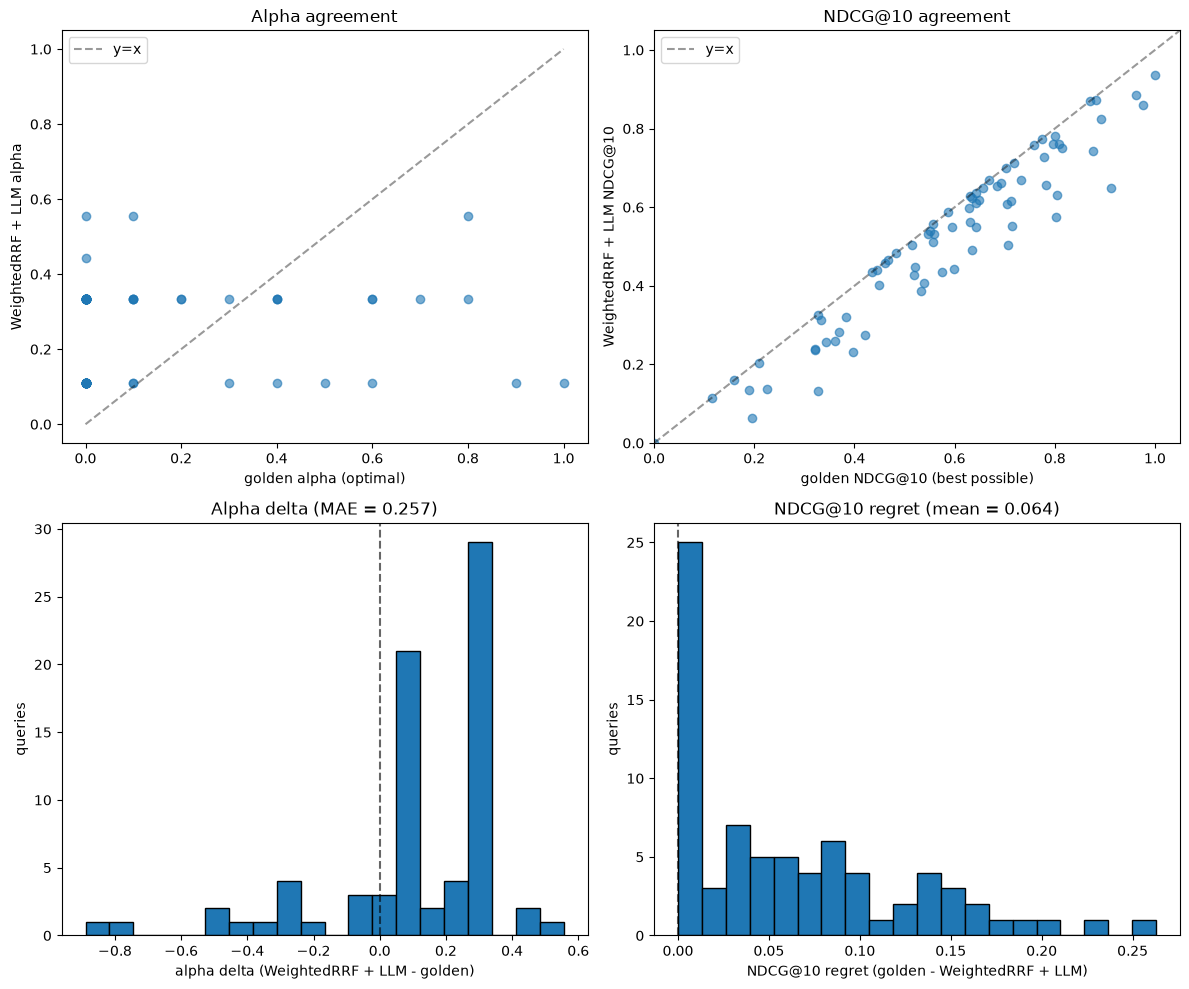

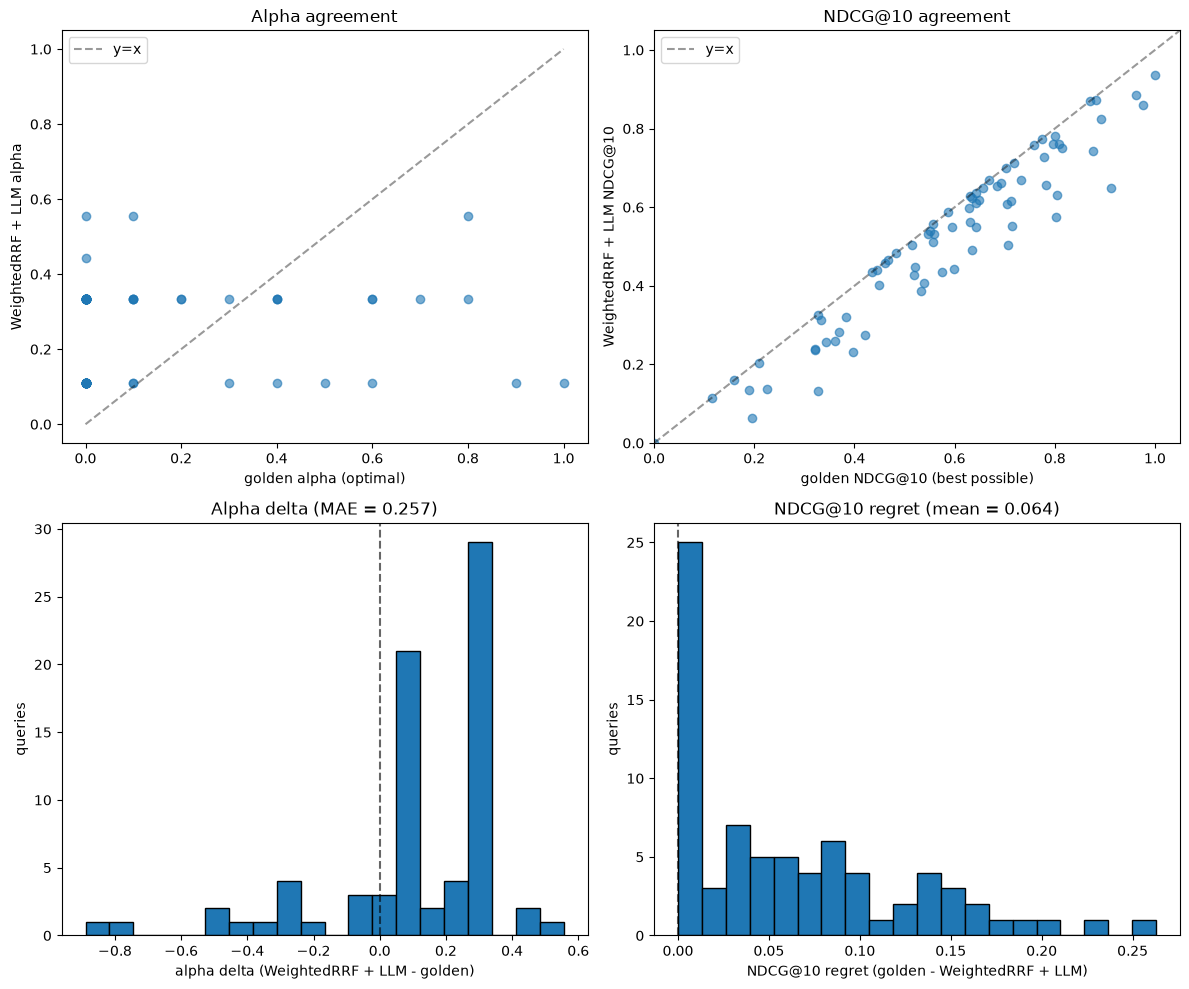

In [35]:
plot_comparison(golden=golden_wrrf, candidate=wrrf_llm_rows, candidate_label="WeightedRRF + LLM")

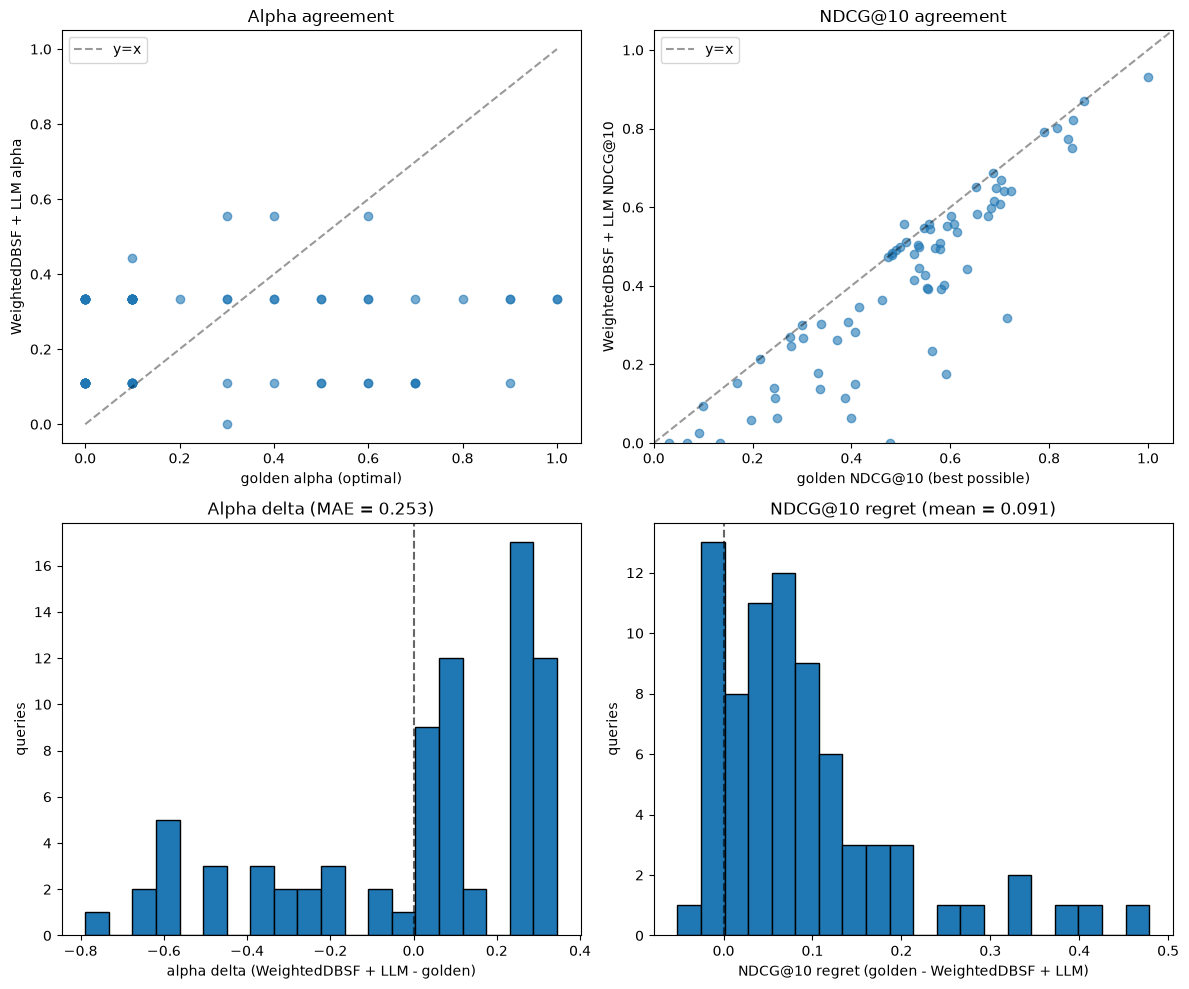

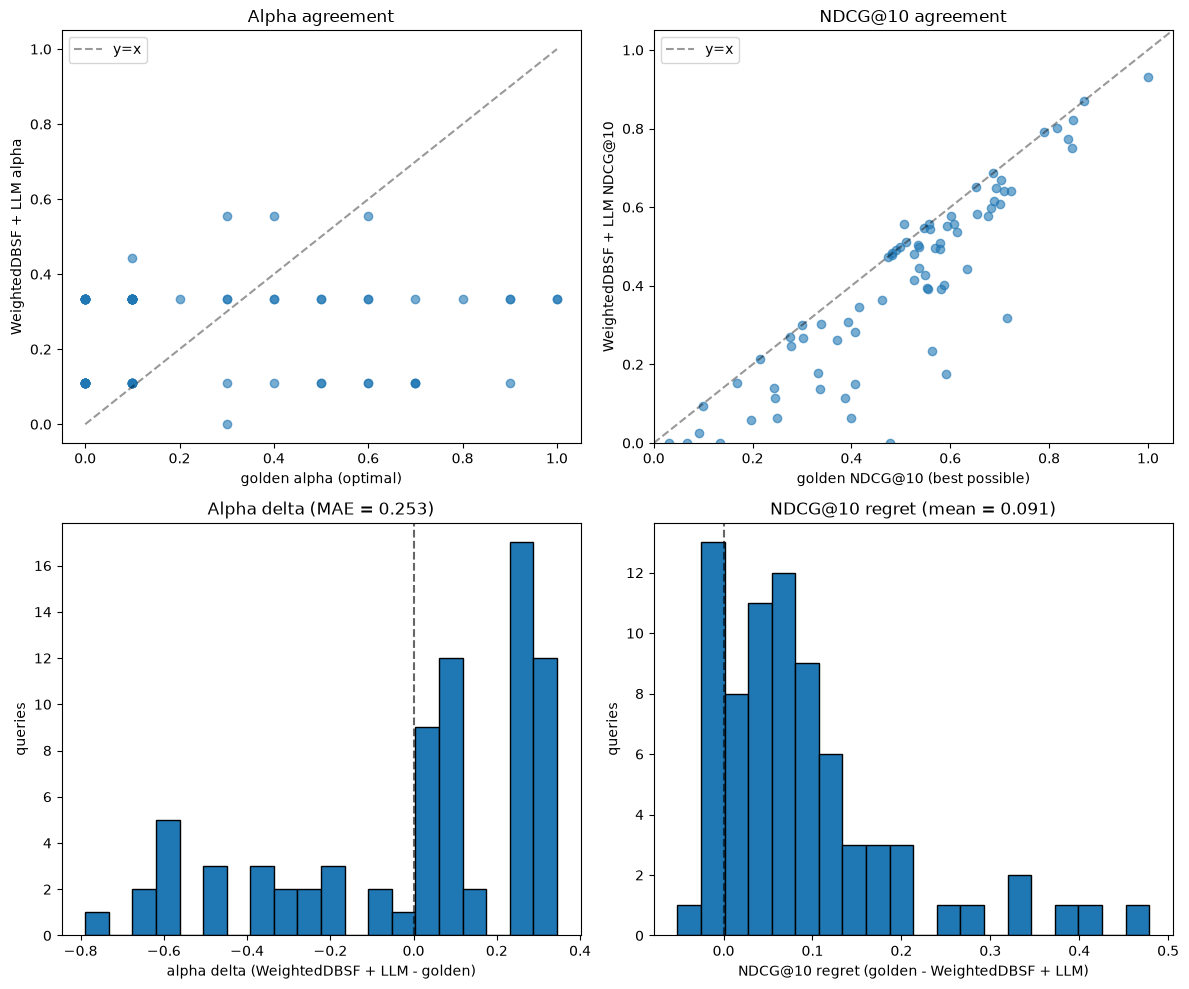

In [36]:
plot_comparison(golden=golden_dbsf, candidate=dbsf_llm_rows, candidate_label="WeightedDBSF + LLM")

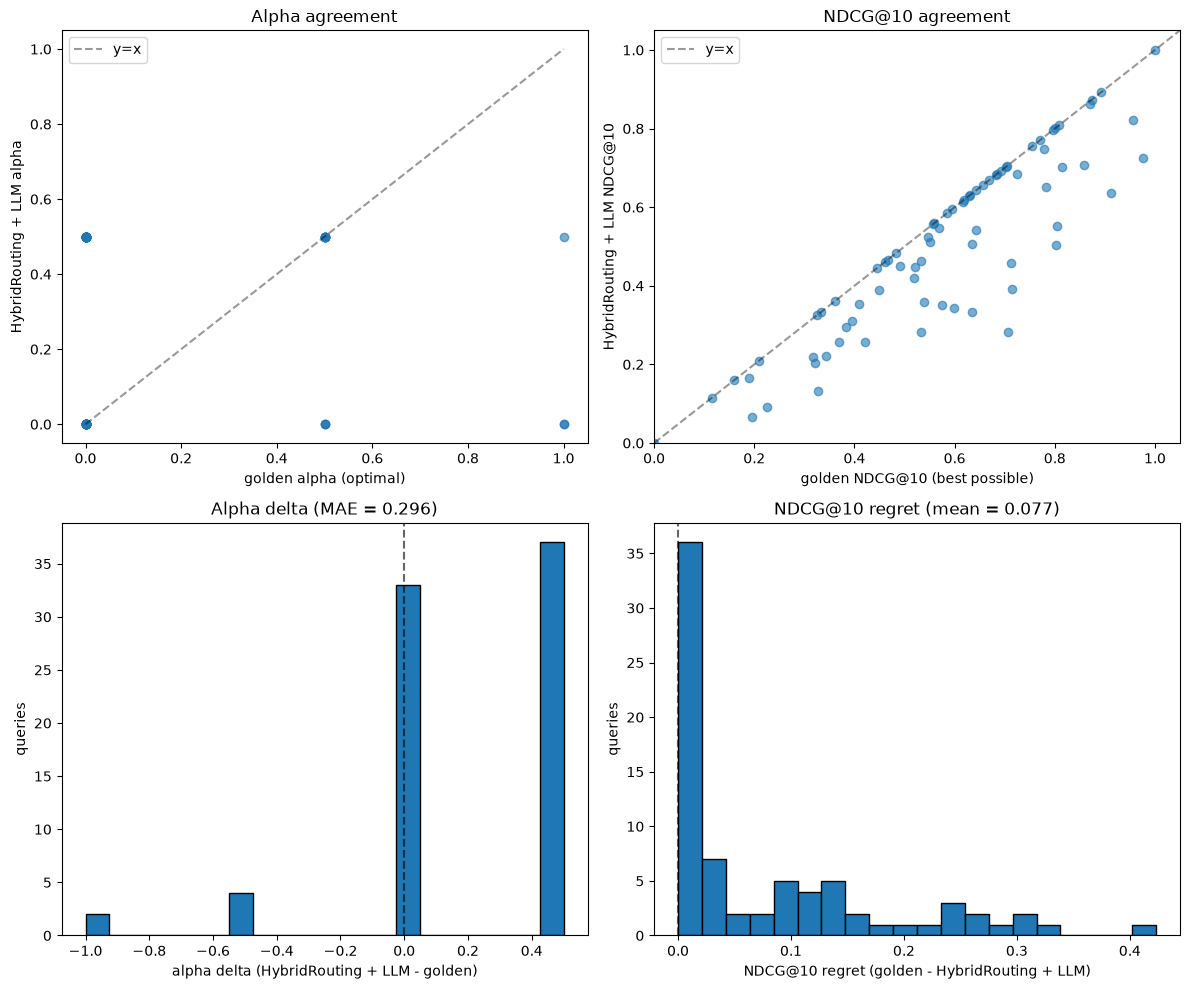

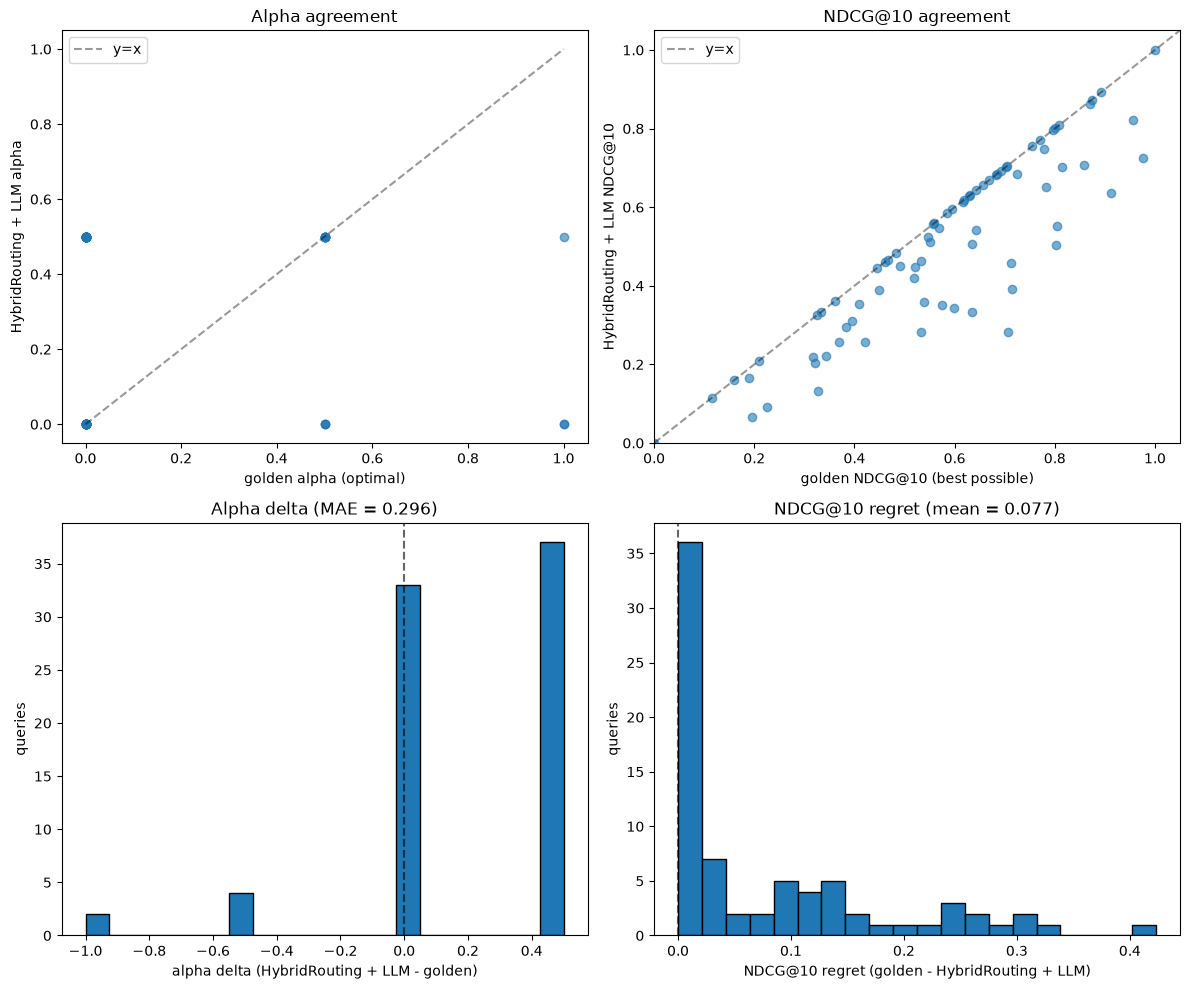

In [37]:
plot_comparison(golden=golden_router, candidate=router_rows, candidate_label="HybridRouting + LLM")

### Results 

1. The adaptive weighting works. There is clear improvement from the LLM based scoring, however, its still suboptimal compared to the golden set. LLM predicted α cuts mean regret roughly in half for RRF (0.126 → 0.064) and improves DBSF meaningfully (0.109 → 0.091). 
2. Golden NDCG differs between RRF and DBSF (0.582 vs 0.506). Some possible explanations: (i) DBSF weighing is application layer implementation, it might be insufficient, while RRF weights are qdrant native (while also being non-convex). (ii) DBSF normalization is hurting the dataset 
3. RRF performs better for this dataset split. LLM+RRF captures 89% of its oracle (0.518/0.582), LLM+DBSF captures 82% of its oracle (0.415/0.506). This is going againts other people finding, but might be the result of the methodology approach taken in this notebook
4. DBSF hits better results than RRF, however in average it performs worse. DBSF+LLM hits the exact oracle configuration 18.4% of the time versus 14.5% for RRF+LLM, despite worse overall regret.
5. The difference in scoring between PureRRF and WeightedRRF proves that the scaling factor is significant for qdrant RRF implementation. PureRRF (0.4563) beats WeightedRRF@(0.5,0.5) (0.4543) because PureRRF has default weights around (1,1).
